In [7]:
! pip install torch torchvision torchaudio ultralytics opencv-python


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import torch
from ultralytics import YOLO
from IPython.display import display
from PIL import Image
import cv2
import random
print(torch.__version__, "\n")
print("YOLO installed successfully")

2.10.0+cpu 

YOLO installed successfully



image 1/1 c:\Users\kamal\OneDrive\Desktop\Image Processing and Computer Vision\LAB8\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 46.7ms
Speed: 2.5ms preprocess, 46.7ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)


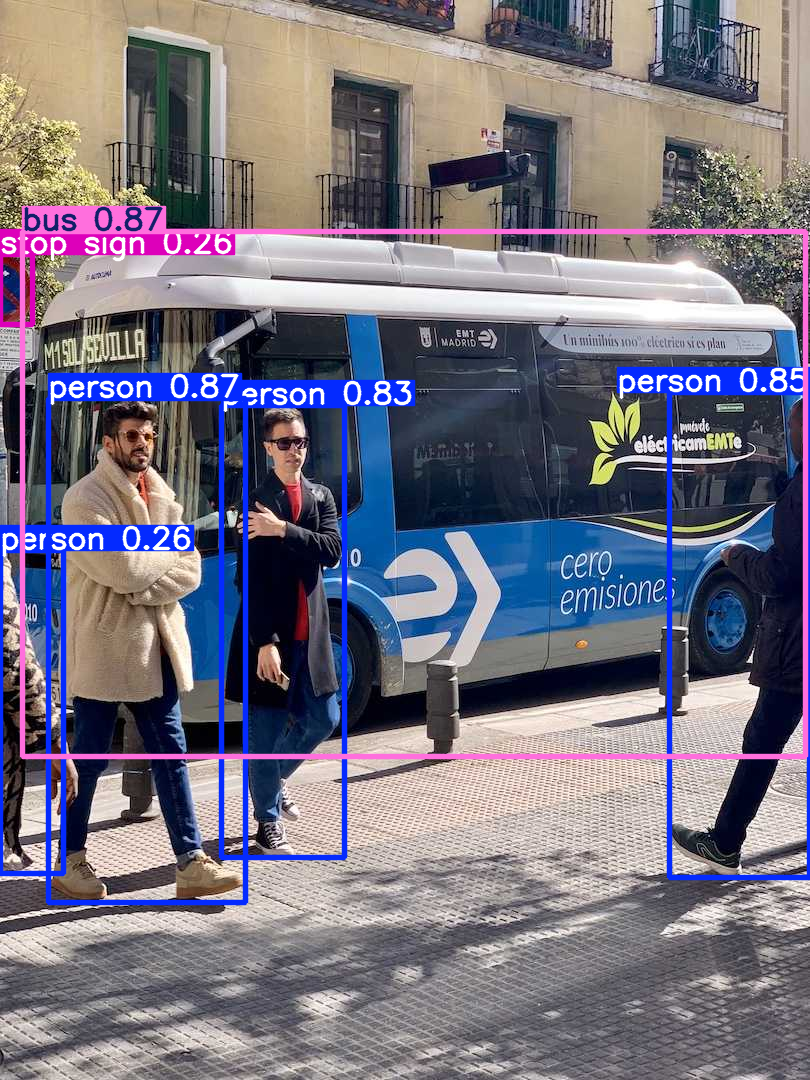

In [9]:
model = YOLO("yolov8n.pt")
results = model("bus.jpg")
img = results[0].plot() # image with detections
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # convert BGR to RGB for correct color display
display(Image.fromarray(img))


image 1/1 c:\Users\kamal\OneDrive\Desktop\Image Processing and Computer Vision\LAB8\test_image.jpg: 480x640 1 bicycle, 1 car, 1 truck, 1 dog, 53.3ms
Speed: 1.6ms preprocess, 53.3ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)


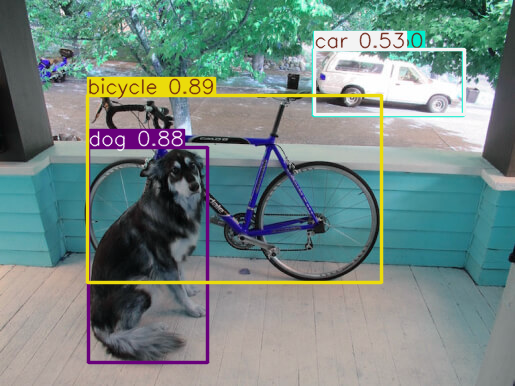

In [10]:
model = YOLO("yolov8n.pt")
results = model("test_image.jpg")
img = results[0].plot() # image with detections
display(Image.fromarray(img))

In [11]:
model = YOLO("yolov8n.pt")
video_path = "input.mp4"
cap = cv2.VideoCapture(video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter("output.mp4", cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
def get_color(cls_id):
     random.seed(cls_id)
     return tuple(random.randint(0, 255) for _ in range(3))
MAX_FRAMES = 100
frame_count = 0
while True:
     ret, frame = cap.read()
     if not ret:
          break
     if frame_count >= MAX_FRAMES:
          print(f"\n Reached limit of {MAX_FRAMES} frames. Stopping...")
          break
     results = model.track(frame, stream=True, verbose=False)
     for result in results:
          for box in result.boxes:
               if box.conf > 0.4:
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    cls_id = int(box.cls[0])
                    conf = float(box.conf[0])
                    track_id = int(box.id[0]) if box.id is not None else 0
                    color = get_color(cls_id)
                    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                    label = f"{result.names[cls_id]} ID:{track_id} {conf:.2f}"
                    cv2.putText(frame, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
     out.write(frame)
     frame_count += 1
     if frame_count % 10 == 0:
          print(f"Processed {frame_count}/{MAX_FRAMES} frames...")
cap.release()
out.release()
print("Motion Tracking Completed. Output saved as 'output.mp4'")

Processed 10/100 frames...
Processed 20/100 frames...
Processed 30/100 frames...
Processed 40/100 frames...
Processed 50/100 frames...
Processed 60/100 frames...
Processed 70/100 frames...
Processed 80/100 frames...
Processed 90/100 frames...
Processed 100/100 frames...

 Reached limit of 100 frames. Stopping...
Motion Tracking Completed. Output saved as 'output.mp4'


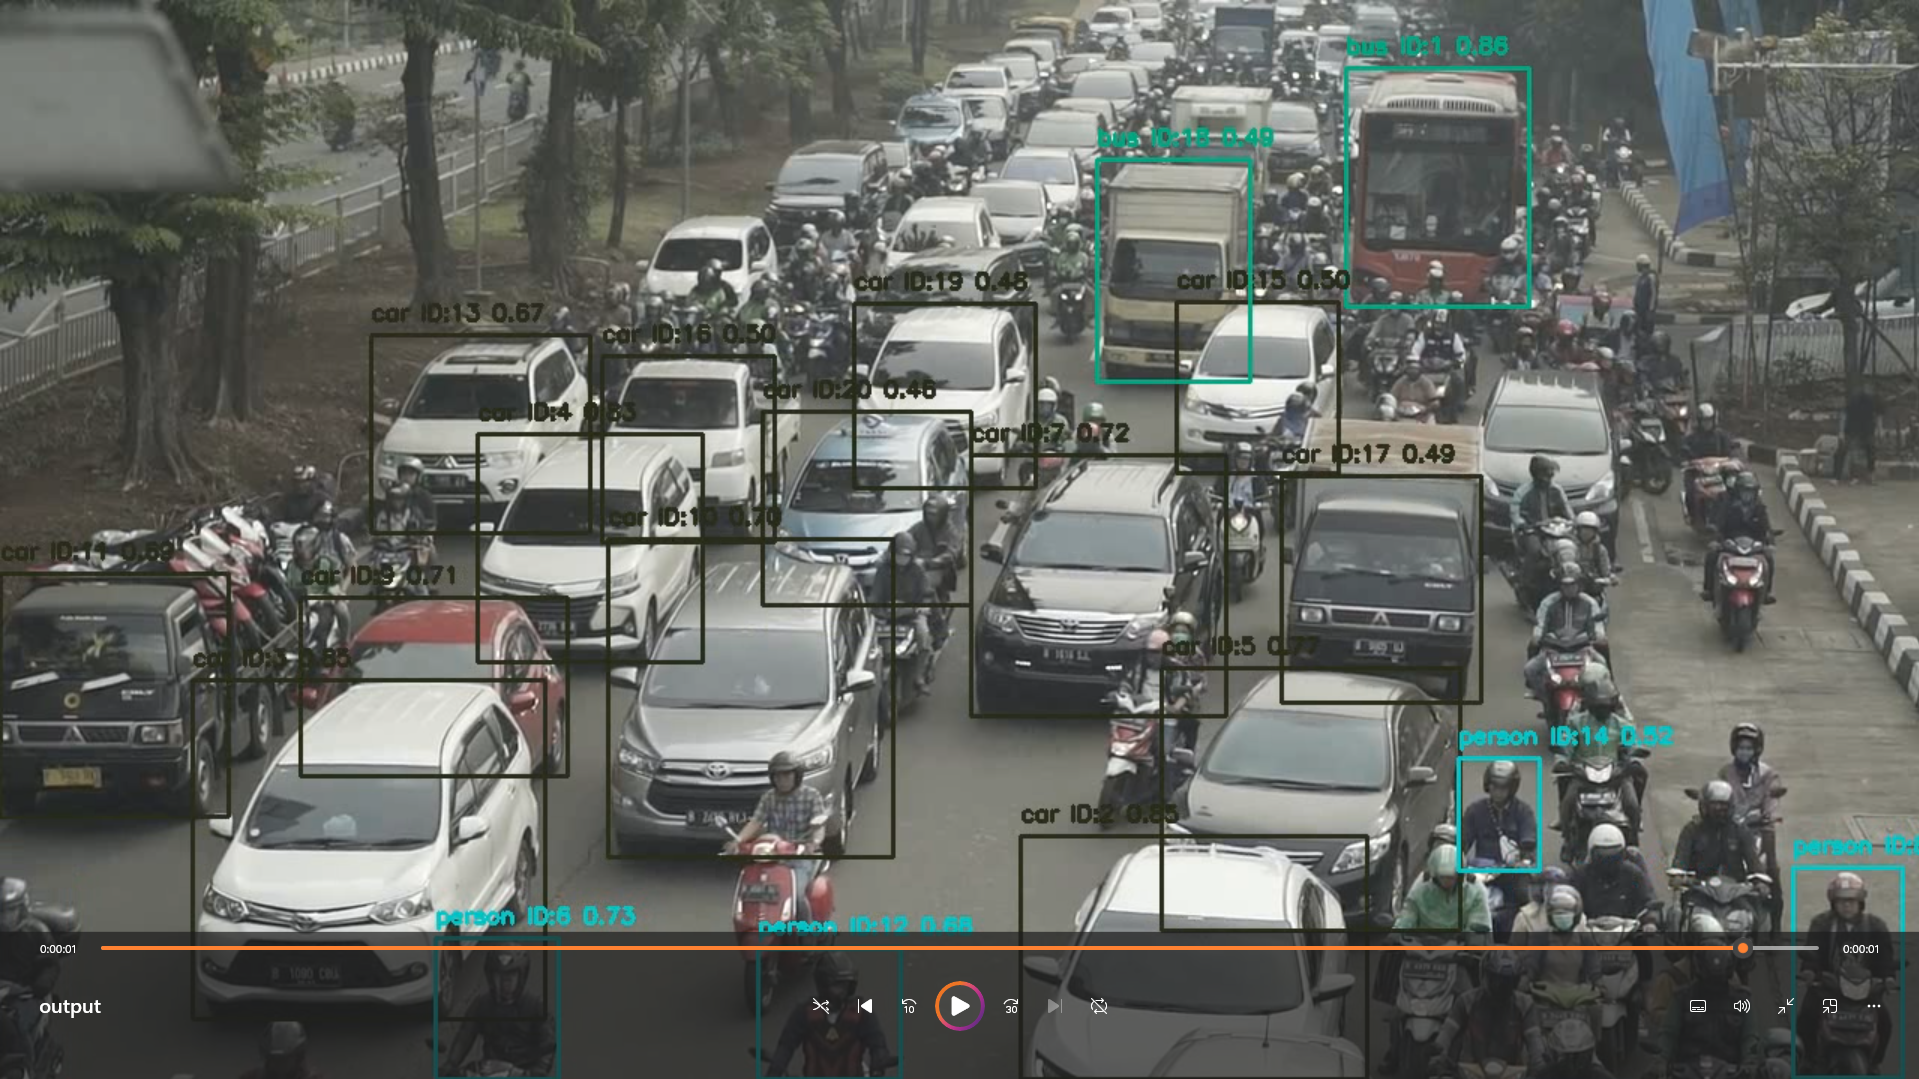

In [12]:
img = Image.open("yolo-video-out.png")
display(img)